In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

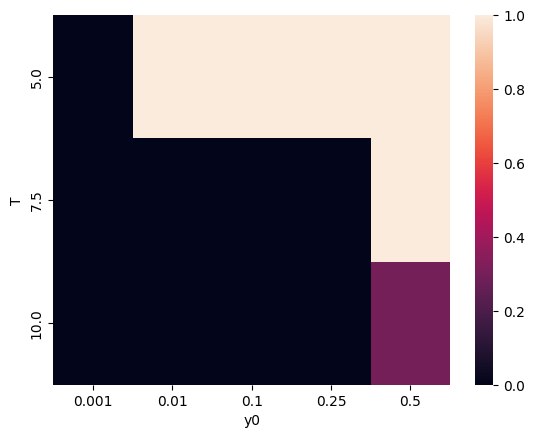

In [2]:
results = pd.read_csv("results_no_reg.csv")

table = pd.pivot_table(results, values="loss_successes_percent", 
                        index=["T"],
                        columns=["y0"],
                        aggfunc="mean")
sns.heatmap(table)
plt.show()

T      1    2    3    4    5     6    7     8     9     10
y0                                                        
0.05  1.0  1.0  1.0  1.0  1.0  0.85  0.0  0.00  0.00  0.00
0.15  1.0  1.0  1.0  1.0  1.0  0.95  0.0  0.00  0.00  0.00
0.25  1.0  1.0  1.0  1.0  1.0  1.00  0.0  0.00  0.00  0.00
0.35  1.0  1.0  1.0  1.0  1.0  1.00  0.0  0.00  0.00  0.00
0.45  1.0  1.0  1.0  1.0  1.0  1.00  0.2  0.35  0.25  0.10
0.55  1.0  1.0  1.0  1.0  1.0  1.00  1.0  0.95  0.95  0.85
0.65  1.0  1.0  1.0  1.0  1.0  1.00  1.0  1.00  1.00  1.00
0.75  1.0  1.0  1.0  1.0  1.0  1.00  1.0  1.00  1.00  1.00
0.85  1.0  1.0  1.0  1.0  1.0  1.00  1.0  1.00  1.00  1.00
0.95  1.0  1.0  1.0  1.0  1.0  1.00  1.0  1.00  1.00  1.00


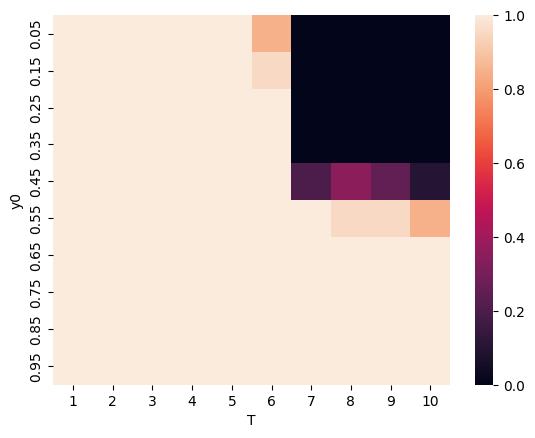

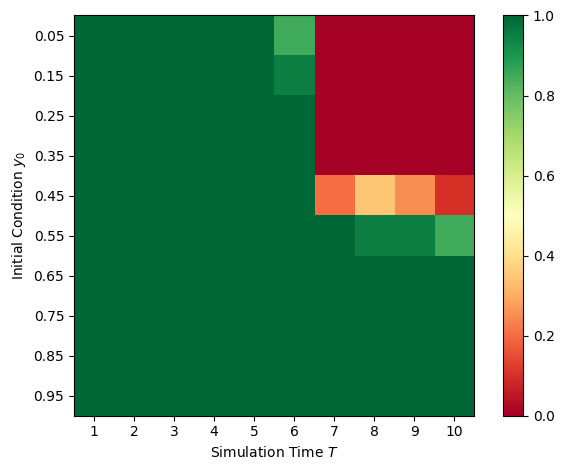

In [3]:
import os 
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

table_list = []
for filename in os.listdir("vanilla_PINN"):
    data = pd.read_csv(f"vanilla_PINN/{filename}")
    table_list.append(data)

table = pd.concat(table_list)

table = pd.pivot_table(table, values="loss_successes_percent", index="y0", columns="T")
table.to_csv("no_reg_results_full.csv")
print(table)
sns.heatmap(table)
plt.show()

fig, ax = plt.subplots()

ims = ax.imshow(table, cmap='RdYlGn')
fig.colorbar(ims)

ax.set_xticks(range(table.shape[1]))
ax.set_xticklabels(table.columns)
ax.set_xlabel(r'Simulation Time $T$')

ax.set_yticks(range(table.shape[0]))
ax.set_yticklabels(table.index)
ax.set_ylabel(r'Initial Condition $y_0$')


plt.tight_layout()
plt.show()

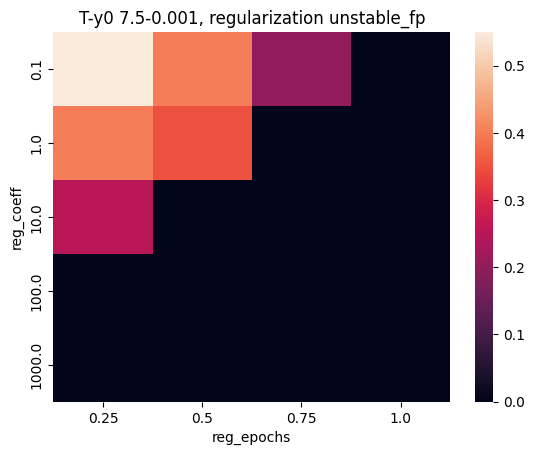

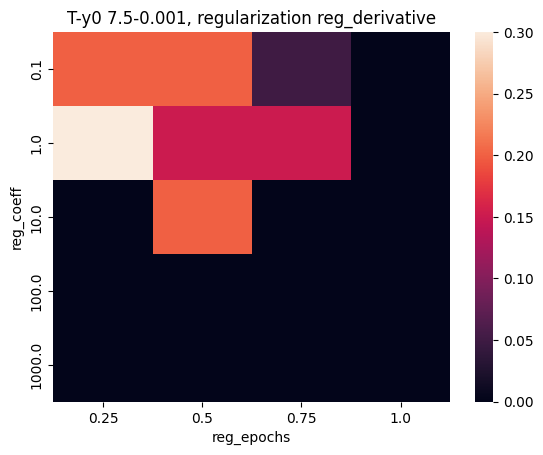

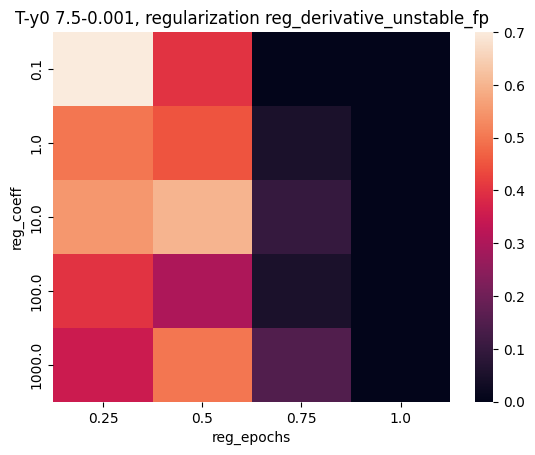

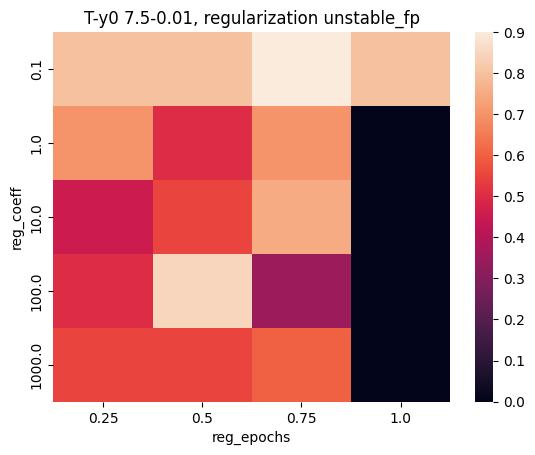

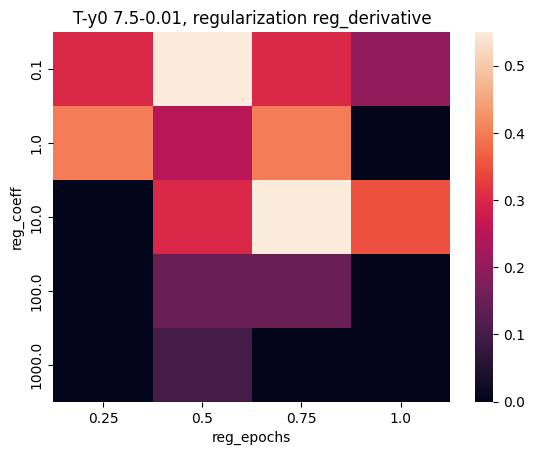

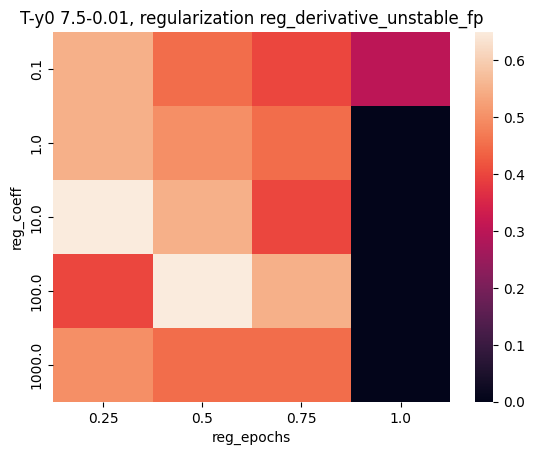

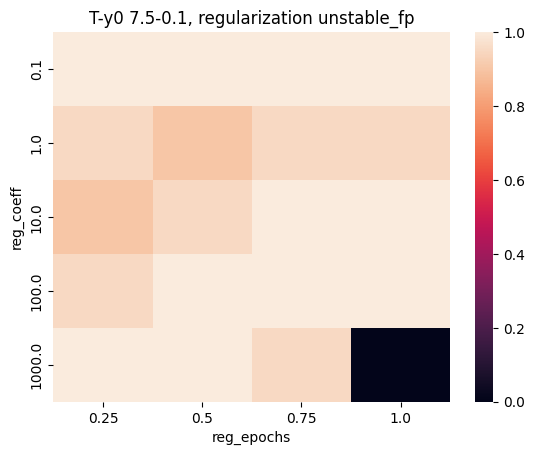

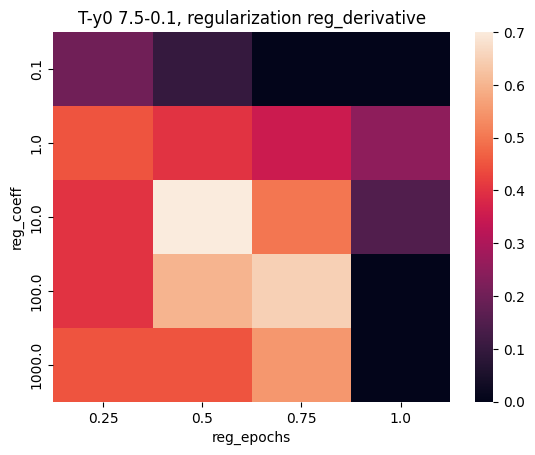

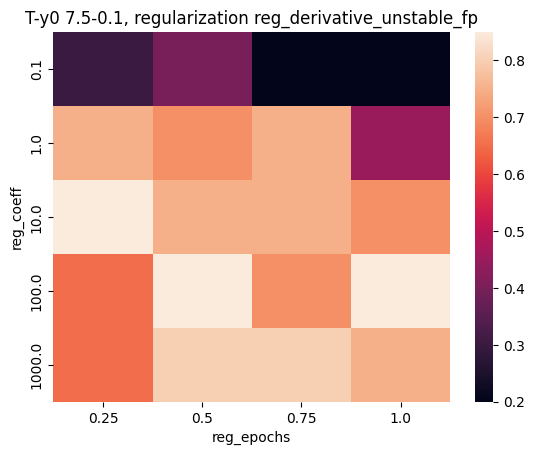

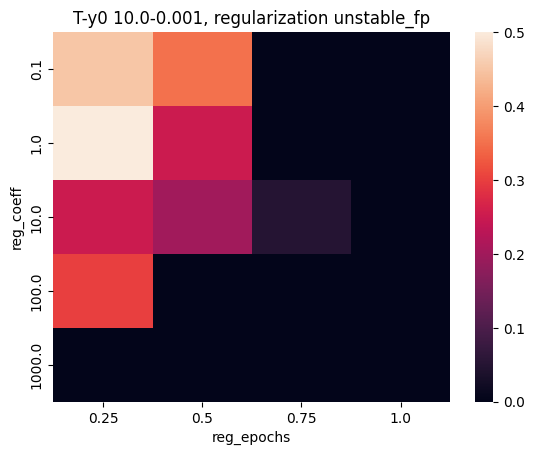

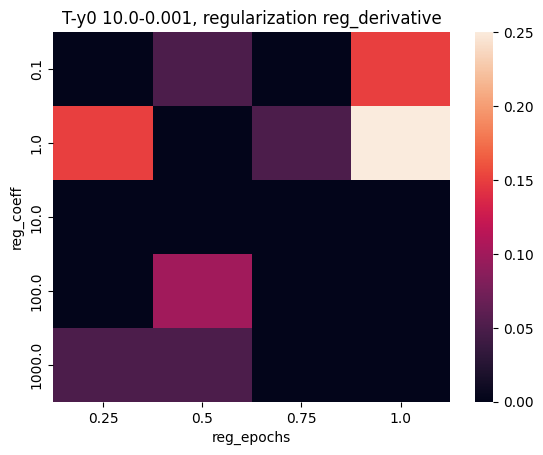

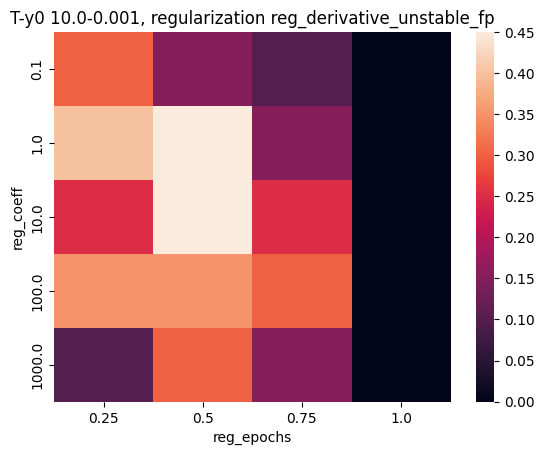

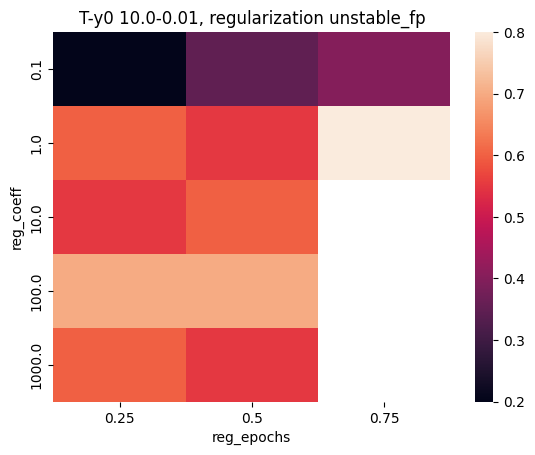

ValueError: zero-size array to reduction operation fmin which has no identity

In [5]:
results = pd.read_csv("results_linear_decay.csv")

results["T-y0"] = results["T"].astype(str) + "-" + results["y0"].astype(str)

for settings in results["T-y0"].unique():
    for regularization in results["regularization"].unique():
        results_subset = results.loc[(results["T-y0"] == settings) & (results["regularization"] == regularization)]
        table = pd.pivot_table(results_subset, values="loss_successes_percent", index="reg_coeff", columns="reg_epochs")
        sns.heatmap(table)
        plt.title(f"T-y0 {settings}, regularization {regularization}")
        plt.show()